# 1. 인공 신경망 Aritificial Neural Network
* 인공신경세포(Perceptron, ~= 인간의 뉴런) -> 인공신경망
* Perceptron 학습의 핵심 알고리즘 : weight 값을 변화시키는 것
    * 오차 |y-y'|가 최소가 되도록 연결강도(w_k)를 조절하는 것이 학습
* 각 노드의 활성화 함수는 계단 함수가 아닌 다양한 비선형 함수를 사용한다.
* 입력층에서 출력층 방향으로 이동하면서 각 입력에 해당하는 가중치를 곱하고, 활성화 함수를 거쳐서 최종 출력까지의 과정을 Forward Propagation(Feed Forward)라고 한다.
* FP에 의한 예측과 실제값의 오차를 출력층에서 입력층 방향으로 전파시키며 각 층의 가중치를 업데이트하는 과정을 Back-Propagation이라고 한다.
* 인공 신경망의 학습은 경사하강법을 통해서 가중치를 업데이트한다.

In [2]:
# 1-1. 단순 선형 회귀
# 데이터 준비
import numpy as np
import matplotlib.pyplot as plt

x = np.array([-1.0, 0.0, 1.0, 2.0, 3.0, 4.0])
y = np.array([5.0, 6.0, 7.0, 8.0, 9.0, 10.0])

print(x.shape, y.shape)

(6,) (6,)


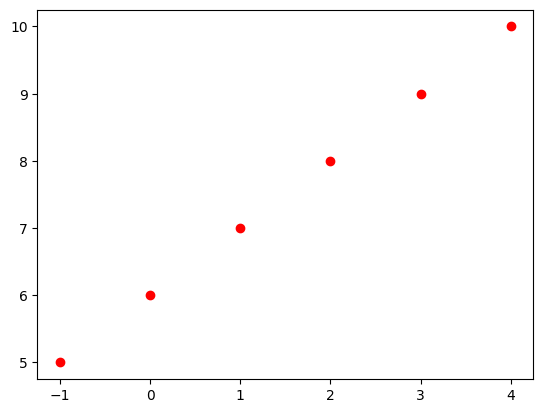

In [3]:
# 데이터 시각화
plt.plot(x, y, 'ro')
plt.show()

In [9]:
# 모델 만들기
# 케라스를 사용해서 유닛이 한 개인 모델을 만든다.
from keras import layers
print(keras.backend.backend())

model = keras.Sequential([
    layers.Dense(1, input_shape=(1,)),
])
model.summary()

torch


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
# 모델의 컴파일
# keras는 모델 학습 전에 컴파일 과정을 거친다. Layer를 쌓는 것이 하드웨어를 만드는 것이라면, 이 단계에서는 어떻게 공부하고 반성할지 결정하는 단계
# 손실함수(혼나는 기준), 옵티마이저(가중치 수정 전략), 메트릭스(사람에게 보여주기 위한 성적표)를 설정한다.

model.compile(optimizer='sgd', loss='mean_squared_error', metrics=['mae'])

In [11]:
# 학습
# 에포크, 배치사이즈 등을 설정해서 학습을 진행한다.
history = model.fit(x,y, epochs=30, verbose=1)
# history 객체 안에는 학습 완료후 모델 학습동안 어떻게 변화했는가에 대한 일기가 저장된다

Epoch 1/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 832ms/step - loss: 70.1998 - mae: 8.0476
Epoch 2/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 58.0148 - mae: 7.4051
Epoch 3/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 48.3710 - mae: 6.8324
Epoch 4/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 40.7276 - mae: 6.3217
Epoch 5/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 34.6594 - mae: 5.8660
Epoch 6/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 29.8314 - mae: 5.4592
Epoch 7/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 25.9804 - mae: 5.0957
Epoch 8/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 22.8990 - mae: 4.7706
Epoch 9/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 20.4242 - mae: 4.4797
Epoch 10/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 18.4277 - mae: 4.2191
Epoch 11/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 16.8084 - mae: 3.9854
Epoch 12/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 15.4871 - mae: 3.7756
Epoch 13/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 14

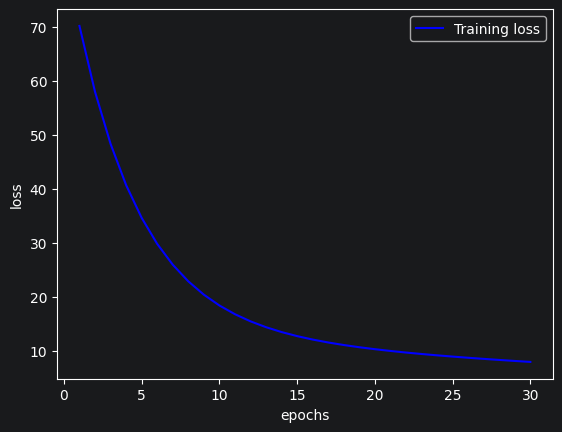

In [13]:
# 학습 결과 시각화
loss = history.history['loss']
epochs = range(1, len(loss) + 1)

plt.plot(epochs, loss, 'b', label='Training loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.show()

In [16]:
# 예측하기
# 학습 완료된 모델에 새로운 데이터를 입력해서 예측한다. 입력 데이터는 배치 차원이 필요해서 한개의 데이터를 입력하더라도 2차원으로 입력해야 한다.
## 모델은 항상 (데이터의 갯수, 데이터의 특징 수)라는 2층 구조의 표를 기대하기 때문
x_test = np.array([[10.0]])
y_pred = model.predict(x_test)
print(y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
[[23.36376]]


In [17]:
# 가중치 출력 : 학습이 오나료된 모델의 가중치를 출력해서 확인
w, b = model.get_weights()
print('w : ', w)
print('b : ', b)

w :  [[2.1078787]]
b :  [2.2849724]


In [18]:
# 예측값의 시각화
y_pred = model.predict(x)
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


array([[ 0.17709374],
       [ 2.2849724 ],
       [ 4.392851  ],
       [ 6.5007296 ],
       [ 8.608608  ],
       [10.716487  ]], dtype=float32)

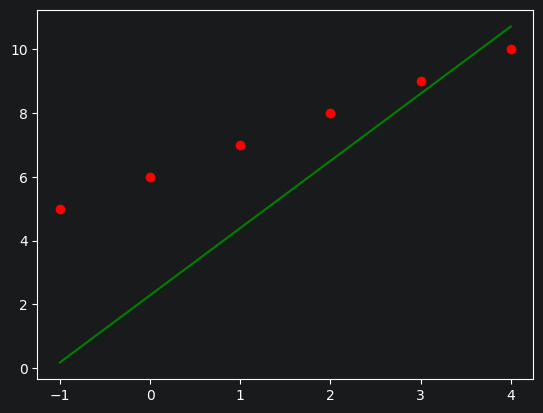

In [19]:
# 시각화 : 원본 데이터와 예측된 직선을 그래프로 변환해본다
plt.plot(x, y, 'ro')
plt.plot(x, y_pred, 'g-')
plt.show()

# 2. 합성곱 신경망 Convolutional Neural Network

# 3. 순환 신경망 Recurrent Neural Network

# 4. TensorFlow